# Ejercicio 01  MLP manual: Iris

Esta es una copia de trabajo. Los notebooks originales no se modifican. Ejecutaremos primero la topologia `4 x 3 x 3` y despues `4 x 3 x 3 x 3 x 3`, manteniendo sigmoide, MSE, `eta=0.03` y 500 epocas.

## Parte A: Corrida orginal `4 x 3 x 3`

Esta es la referencia. No se cambia la funcion de activacion, la perdida, la tasa ni las epocas.

In [31]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.utils import to_categorical
from sklearn import datasets

iris = datasets.load_iris()
X = iris.data
target = iris.target
Y = to_categorical(target).astype("uint8")


In [32]:
idx = 0
print(X[idx])
print(target[idx])
print(Y[idx])
idx = 50
print(X[idx])
print(target[idx])
print(Y[idx])
idx = 100
print(X[idx])
print(target[idx])
print(Y[idx])

[5.1 3.5 1.4 0.2]
0
[1 0 0]
[7.  3.2 4.7 1.4]
1
[0 1 0]
[6.3 3.3 6.  2.5]
2
[0 0 1]


In [33]:
def generate_weights(num_weights):
    w = np.zeros(num_weights)
    for i in range(len(w)):
        w[i] = (np.random.rand(1)[0] - 0.5)
    return w

def net_input(input_vector, w):
    net_input_var = w[0]
    for i in range(len(input_vector)):
        net_input_var += w[i+1] * input_vector[i]
    return net_input_var

def sigmoid(z):
    activation = 1 / (1 + np.power(np.e, -z))
    return activation

def propagate(X_in, w):
    neuronInput = net_input(X_in, w)
    neuronOutput = sigmoid(neuronInput)
    return neuronOutput

In [34]:
# Topología Original: 4 x 3 x 3
input_size_layer1 = 4
num_neurons_layer1 = 3

input_size_layer2 = num_neurons_layer1
num_neurons_layer2 = 3

layer1 = list()
layer2 = list()

def init_weights_original():
    layer1.clear()
    layer2.clear()
    for i in range(num_neurons_layer1):
        layer1.append(generate_weights(input_size_layer1 + 1))
    for i in range(num_neurons_layer2):
        layer2.append(generate_weights(input_size_layer2 + 1))

def calculate_error_original():
    total_err = 0
    for idx in range(len(X)):
        output_layer1 = np.zeros(num_neurons_layer1)
        for i in range(len(output_layer1)):
            output_layer1[i] = propagate(X[idx], layer1[i])

        output_layer2 = np.zeros(num_neurons_layer2)
        for i in range(len(output_layer2)):
            output_layer2[i] = propagate(output_layer1, layer2[i])

        err = Y[idx] - output_layer2
        err = np.power(err, 2)
        total_err += err.sum()

    return total_err / (len(X))


Original 4x3x3 - Error inicial: 0.824421 | Error final: 0.086393


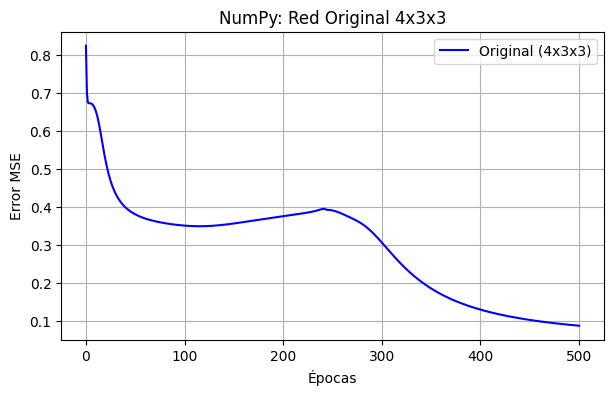

In [35]:
alpha = 0.03
epochs = 500

init_weights_original()

E_orig = list()
E_orig.append(calculate_error_original())

for e in range(epochs):
    for d in range(len(X)):
        # Etapa 1 - Propagación hacia adelante
        output_layer1 = np.zeros(num_neurons_layer1)
        for i in range(len(output_layer1)):
            output_layer1[i] = propagate(X[d], layer1[i])

        output_layer2 = np.zeros(num_neurons_layer2)
        for i in range(len(output_layer2)):
            output_layer2[i] = propagate(output_layer1, layer2[i])

        # Etapa 2 - Retropropagación capa 2 (Salida)
        delta_layer2 = np.zeros(num_neurons_layer2)
        for i in range(len(delta_layer2)):
            delta_layer2[i] = output_layer2[i] * (1 - output_layer2[i]) * (Y[d][i] - output_layer2[i])

        # Actualización de pesos capa 2
        for i in range(len(layer2)):
            layer2[i][0] += alpha * delta_layer2[i] * 1
            for j in range(len(layer2[i]) - 1):
                layer2[i][j+1] += alpha * delta_layer2[i] * output_layer1[j]

        # Retropropagación capa 1 (Oculta)
        delta_layer1 = np.zeros(num_neurons_layer1)
        for i in range(len(delta_layer1)):
            weighted_delta_errors = 0
            for j in range(num_neurons_layer2):
                weighted_delta_errors += layer2[j][i+1] * delta_layer2[j]
            delta_layer1[i] = output_layer1[i] * (1 - output_layer1[i]) * weighted_delta_errors

        # Actualización de pesos capa 1
        for i in range(len(layer1)):
            layer1[i][0] += alpha * delta_layer1[i] * 1
            for j in range(len(layer1[i]) - 1):
                layer1[i][j+1] += alpha * delta_layer1[i] * X[d][j]

    E_orig.append(calculate_error_original())

print(f"Original 4x3x3 - Error inicial: {E_orig[0]:.6f} | Error final: {E_orig[-1]:.6f}")

plt.figure(figsize=(7, 4))
plt.plot(E_orig, label="Original (4x3x3)", color="blue")
plt.xlabel("Épocas")
plt.ylabel("Error MSE")
plt.title("NumPy: Red Original 4x3x3")
plt.grid(True)
plt.legend()
plt.show()

## Parte B: Corrida profunda `4 x 3 x 3 x 3 x 3`

Se agregan exactamente dos capas ocultas de tres neuronas. La salida continua teniendo tres neuronas.

In [36]:
# Topología Profunda requerida: 4 x 3 x 3 x 3 x 3
input_size_d1 = 4
num_neurons_d1 = 3

input_size_d2 = 3
num_neurons_d2 = 3

input_size_d3 = 3
num_neurons_d3 = 3

input_size_d4 = 3
num_neurons_d4 = 3

deep_layer1 = list()
deep_layer2 = list()
deep_layer3 = list()
deep_layer4 = list()

def init_weights_deep():
    deep_layer1.clear()
    deep_layer2.clear()
    deep_layer3.clear()
    deep_layer4.clear()
    
    for i in range(num_neurons_d1):
        deep_layer1.append(generate_weights(input_size_d1 + 1))
    for i in range(num_neurons_d2):
        deep_layer2.append(generate_weights(input_size_d2 + 1))
    for i in range(num_neurons_d3):
        deep_layer3.append(generate_weights(input_size_d3 + 1))
    for i in range(num_neurons_d4):
        deep_layer4.append(generate_weights(input_size_d4 + 1))

def calculate_error_deep():
    total_err = 0
    for idx in range(len(X)):
        out1 = np.zeros(num_neurons_d1)
        for i in range(len(out1)):
            out1[i] = propagate(X[idx], deep_layer1[i])

        out2 = np.zeros(num_neurons_d2)
        for i in range(len(out2)):
            out2[i] = propagate(out1, deep_layer2[i])

        out3 = np.zeros(num_neurons_d3)
        for i in range(len(out3)):
            out3[i] = propagate(out2, deep_layer3[i])

        out4 = np.zeros(num_neurons_d4)
        for i in range(len(out4)):
            out4[i] = propagate(out3, deep_layer4[i])

        err = Y[idx] - out4
        total_err += np.sum(np.power(err, 2))

    return total_err / (len(X))

Profunda 4x3x3x3x3 - Error inicial: 0.772731 | Error final: 0.283513


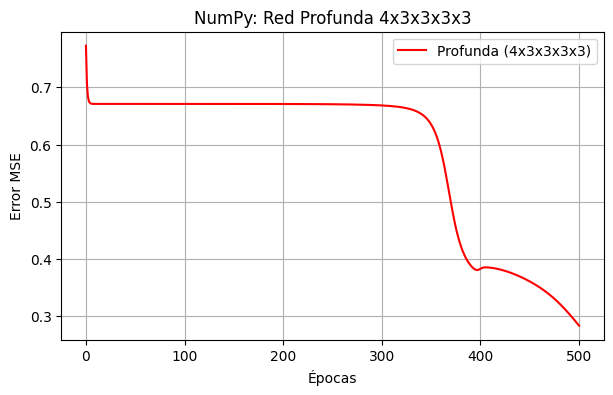

In [37]:
init_weights_deep()

E_deep = list()
E_deep.append(calculate_error_deep())

for e in range(epochs):
    for d in range(len(X)):
        # 1. Forward Pass (Capa 1 a 4)
        out1 = np.zeros(num_neurons_d1)
        for i in range(len(out1)):
            out1[i] = propagate(X[d], deep_layer1[i])

        out2 = np.zeros(num_neurons_d2)
        for i in range(len(out2)):
            out2[i] = propagate(out1, deep_layer2[i])

        out3 = np.zeros(num_neurons_d3)
        for i in range(len(out3)):
            out3[i] = propagate(out2, deep_layer3[i])

        out4 = np.zeros(num_neurons_d4)
        for i in range(len(out4)):
            out4[i] = propagate(out3, deep_layer4[i])

        # 2. Backpropagation: Deltas de la capa de salida (Capa 4)
        delta4 = np.zeros(num_neurons_d4)
        for i in range(len(delta4)):
            delta4[i] = out4[i] * (1 - out4[i]) * (Y[d][i] - out4[i])

        # Actualización de pesos Capa 4
        for i in range(len(deep_layer4)):
            deep_layer4[i][0] += alpha * delta4[i] * 1
            for j in range(len(deep_layer4[i]) - 1):
                deep_layer4[i][j+1] += alpha * delta4[i] * out3[j]

        # 3. Deltas Capa 3 (Oculta)
        delta3 = np.zeros(num_neurons_d3)
        for i in range(len(delta3)):
            sum_err = 0
            for j in range(num_neurons_d4):
                sum_err += deep_layer4[j][i+1] * delta4[j]
            delta3[i] = out3[i] * (1 - out3[i]) * sum_err

        # Actualización de pesos Capa 3
        for i in range(len(deep_layer3)):
            deep_layer3[i][0] += alpha * delta3[i] * 1
            for j in range(len(deep_layer3[i]) - 1):
                deep_layer3[i][j+1] += alpha * delta3[i] * out2[j]

        # 4. Deltas Capa 2 (Oculta)
        delta2 = np.zeros(num_neurons_d2)
        for i in range(len(delta2)):
            sum_err = 0
            for j in range(num_neurons_d3):
                sum_err += deep_layer3[j][i+1] * delta3[j]
            delta2[i] = out2[i] * (1 - out2[i]) * sum_err

        # Actualización de pesos Capa 2
        for i in range(len(deep_layer2)):
            deep_layer2[i][0] += alpha * delta2[i] * 1
            for j in range(len(deep_layer2[i]) - 1):
                deep_layer2[i][j+1] += alpha * delta2[i] * out1[j]

        # 5. Deltas Capa 1 (Oculta inicial)
        delta1 = np.zeros(num_neurons_d1)
        for i in range(len(delta1)):
            sum_err = 0
            for j in range(num_neurons_d2):
                sum_err += deep_layer2[j][i+1] * delta2[j]
            delta1[i] = out1[i] * (1 - out1[i]) * sum_err

        # Actualización de pesos Capa 1
        for i in range(len(deep_layer1)):
            deep_layer1[i][0] += alpha * delta1[i] * 1
            for j in range(len(deep_layer1[i]) - 1):
                deep_layer1[i][j+1] += alpha * delta1[i] * X[d][j]

    E_deep.append(calculate_error_deep())

print(f"Profunda 4x3x3x3x3 - Error inicial: {E_deep[0]:.6f} | Error final: {E_deep[-1]:.6f}")

plt.figure(figsize=(7, 4))
plt.plot(E_deep, label="Profunda (4x3x3x3x3)", color="red")
plt.xlabel("Épocas")
plt.ylabel("Error MSE")
plt.title("NumPy: Red Profunda 4x3x3x3x3")
plt.grid(True)
plt.legend()
plt.show()

## Paso 5  Comparacion manual

La grafica conjunta y la tabla permiten comparar las dos corridas con la misma metrica.

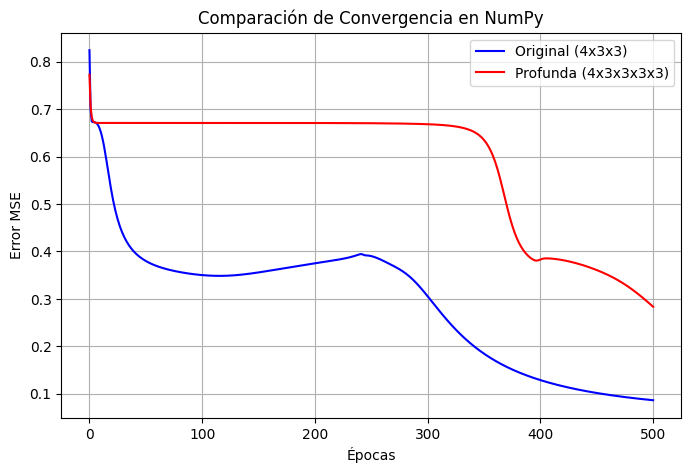

In [38]:
plt.figure(figsize=(8, 5))
plt.plot(E_orig, label="Original (4x3x3)", color="blue")
plt.plot(E_deep, label="Profunda (4x3x3x3x3)", color="red")
plt.xlabel("Épocas")
plt.ylabel("Error MSE")
plt.title("Comparación de Convergencia en NumPy")
plt.grid(True)
plt.legend()
plt.show()

## Reto opcional  aplanamiento cada 50 epocas

La siguiente salida ayuda a observar cundo la curva deja de mejorar. Se mantiene la misma configuracion.

In [39]:
print("=" * 60)
print(f"{'Época':^8} | {'Error (4x3x3)':^22} | {'Error (4x3x3x3x3)':^22}")
print("=" * 60)

for epoch in range(0, len(E_orig), 50):
    err_orig = E_orig[epoch]
    err_deep = E_deep[epoch]
    print(f"{epoch:^8d} | {err_orig:^22.6f} | {err_deep:^22.6f}")

# Imprimir la última época (época 500) en caso de que el rango no la alcance exactamente
if (len(E_orig) - 1) % 50 != 0:
    last_ep = len(E_orig) - 1
    print(f"{last_ep:^8d} | {E_orig[last_ep]:^22.6f} | {E_deep[last_ep]:^22.6f}")

print("=" * 60)


 Época   |     Error (4x3x3)      |   Error (4x3x3x3x3)   
   0     |        0.824421        |        0.772731       
   50    |        0.379968        |        0.671077       
  100    |        0.350246        |        0.671088       
  150    |        0.355888        |        0.671061       
  200    |        0.375034        |        0.670948       
  250    |        0.390295        |        0.670493       
  300    |        0.305621        |        0.668400       
  350    |        0.184541        |        0.635097       
  400    |        0.128824        |        0.383179       
  450    |        0.101642        |        0.360857       
  500    |        0.086393        |        0.283513       
